# IDR Metrics Analysis

This notebook analyzes interdisciplinarity metrics exported at three levels:

- paper or team level,
- people level, and
- community level.

The current workflow computes Shannon entropy, normalized Shannon entropy, Blau index, HHI, and Rao-Stirling diversity.


## Environment Check


In [13]:
import sys
print(sys.executable)


/Users/dharani/Desktop/PSI/env/bin/python


In [14]:
%pip install -r "../requirements.txt"



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load Exported IDR Tables

Run `python3 scripts/export_idr_metrics.py` whenever the underlying filtered papers or centrality/community outputs change.


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

paper_idr_df = pd.read_csv("../data/idr_papers.csv")
people_idr_df = pd.read_csv("../data/idr_people.csv")
community_idr_df = pd.read_csv("../data/idr_communities.csv")

paper_idr_df.head()


,paper_id,DOI,title,year,team_size,nc_team_size,external_team_size,topics,num_topics,shannon_entropy,normalized_shannon,blau_index,hhi,rao_stirling
0,10.1002/2015wr017897,10.1002/2015wr017897,Calibration of soil moisture sensing with subs...,2016,6,1,5,carbon capture; materials engineering; modelin...,5,1.609438,1.0,0.800000,0.200000,0.324622
1,10.1002/2016WR020196,10.1002/2016WR020196,Temporal variability in the importance of hydr...,2017,5,1,4,NaN,0,0.000000,0.0,0.000000,0.000000,0.000000
2,10.1002/2017gl073499,10.1002/2017gl073499,Failure of Taylor's hypothesis in the atmosphe...,2017,7,1,6,sensing,1,-0.000000,0.0,0.000000,1.000000,0.000000
3,10.1002/2017wr021730,10.1002/2017wr021730,Spatial Patterns of Development Drive Water Use,2018,5,2,3,carbon capture; community; conservation; data ...,22,3.091042,1.0,0.954545,0.045455,0.315454
4,10.1002/9781118883303.ch4,10.1002/9781118883303.ch4,A Proteomic-Based Quantitative Analysis of the...,2016,16,3,13,Ag economics; Agtech; artificial intelligence;...,67,4.204693,1.0,0.985075,0.014925,0.356084


In [16]:
summary = pd.Series({
    "papers_with_idr": len(paper_idr_df),
    "people_with_idr": len(people_idr_df),
    "communities_with_idr": len(community_idr_df),
    "nc_people_with_idr": int(people_idr_df["nc_state"].sum()),
    "median_paper_rao": float(paper_idr_df["rao_stirling"].median()),
    "median_people_rao": float(people_idr_df["rao_stirling"].median()),
    "median_community_rao": float(community_idr_df["rao_stirling"].median()),
})
summary


papers_with_idr          2743.000000
people_with_idr         10032.000000
communities_with_idr       47.000000
nc_people_with_idr        984.000000
median_paper_rao            0.014228
median_people_rao           0.014228
median_community_rao        0.145312
dtype: float64

## Important Interpretation Note

People-level IDR can be artificially high for authors with only one paper, especially when that one paper has many topics. For that reason, this notebook shows both full rankings and filtered rankings based on minimum paper counts.


In [17]:
people_2plus_df = people_idr_df[people_idr_df["paper_count"] >= 2].copy()
people_3plus_df = people_idr_df[people_idr_df["paper_count"] >= 3].copy()
nc_people_2plus_df = people_2plus_df[people_2plus_df["nc_state"]].copy()
nc_people_3plus_df = people_3plus_df[people_3plus_df["nc_state"]].copy()

pd.Series({
    "people_with_2plus_papers": len(people_2plus_df),
    "people_with_3plus_papers": len(people_3plus_df),
    "nc_people_with_2plus_papers": len(nc_people_2plus_df),
    "nc_people_with_3plus_papers": len(nc_people_3plus_df),
})


people_with_2plus_papers       2743
people_with_3plus_papers       1417
nc_people_with_2plus_papers     545
nc_people_with_3plus_papers     346
dtype: int64

## Conclusions

These are plain-language takeaways from the current IDR exports.


In [18]:
top_nc_person = nc_people_3plus_df.nlargest(1, "rao_stirling")
top_community = community_idr_df.nlargest(1, "rao_stirling")
top_paper = paper_idr_df.nlargest(1, "rao_stirling")

conclusions_df = pd.DataFrame([
    {
        "finding": "People-level IDR coverage",
        "conclusion": f"The current people-level export covers {len(people_idr_df):,} authors, including {int(people_idr_df['nc_state'].sum()):,} NC State authors."
    },
    {
        "finding": "People-level interpretation",
        "conclusion": "Single-paper authors can rank very high on IDR if that one paper spans many topics, so filtered rankings using minimum paper thresholds are more meaningful for interpretation."
    },
    {
        "finding": "Top NC author by IDR (3+ papers)",
        "conclusion": f"Among NC State authors with at least 3 papers, the current leader by Rao-Stirling diversity is {top_nc_person.iloc[0]['author']} with Rao-Stirling {top_nc_person.iloc[0]['rao_stirling']:.3f} across {int(top_nc_person.iloc[0]['num_topics'])} topics and {int(top_nc_person.iloc[0]['paper_count'])} papers." if not top_nc_person.empty else "No NC State author met the current threshold."
    },
    {
        "finding": "Community-level IDR",
        "conclusion": f"The community-level export covers {len(community_idr_df):,} communities. The current top community by Rao-Stirling is {int(top_community.iloc[0]['community'])} with Rao-Stirling {top_community.iloc[0]['rao_stirling']:.3f}."
    },
    {
        "finding": "Paper-level IDR",
        "conclusion": f"At the paper or team level, the current highest Rao-Stirling score is {top_paper.iloc[0]['rao_stirling']:.3f} for the paper \"{top_paper.iloc[0]['title']}\"."
    },
])
conclusions_df


,finding,conclusion
0,People-level IDR coverage,"The current people-level export covers 10,032 ..."
1,People-level interpretation,Single-paper authors can rank very high on IDR...
2,Top NC author by IDR (3+ papers),"Among NC State authors with at least 3 papers,..."
3,Community-level IDR,The community-level export covers 47 communiti...
4,Paper-level IDR,"At the paper or team level, the current highes..."


## Top People By IDR


In [19]:
people_idr_df.nlargest(15, "rao_stirling")[["author", "nc_state", "paper_count", "num_topics", "rao_stirling", "normalized_shannon"]]


,author,nc_state,paper_count,num_topics,rao_stirling,normalized_shannon
0,"Choe, Kisurb",False,1,4,0.486769,1.0
1,"Thomas, Anna",False,1,4,0.486769,1.0
2,"Brawner, Jeremy",False,1,7,0.439459,1.0
3,"Hudson, Owen",False,1,7,0.439459,1.0
4,"Messina, Charlie",False,1,7,0.439459,1.0
5,"Resende Jr, Marcio F. R.",False,1,7,0.439459,1.0
6,"Crawford, Kerri M.",False,1,9,0.437158,1.0
7,"Bello-Bello, Elohim",False,1,11,0.431709,1.0
8,"Olalde-Portugal, Victor",False,1,11,0.431709,1.0
9,"Rosario Ramirez-Flores, M.",False,1,11,0.431709,1.0


In [20]:
nc_people_3plus_df.nlargest(20, "rao_stirling")[["author", "paper_count", "num_topics", "rao_stirling", "normalized_shannon", "blau_index"]]


,author,paper_count,num_topics,rao_stirling,normalized_shannon,blau_index
53,"Hossain, Tasmin",4,67,0.360934,0.997567,0.984765
55,"Thapa, Resham",10,67,0.360439,0.996517,0.984629
56,"Gilleskie, Gary",3,67,0.360405,0.983932,0.982500
57,"Pancorbo, Jennifer",3,67,0.360405,0.983932,0.982500
67,"Bellcase, Leah",3,67,0.359363,0.995142,0.984453
69,"Carter, David",3,67,0.359363,0.995142,0.984453
70,"Cook, Rachel",3,67,0.359363,0.995142,0.984453
81,"He, Weilong",4,67,0.359029,0.991681,0.984037
95,"Wells, Randy",3,65,0.357651,0.990721,0.983487
123,"Osmond, Deanna",4,67,0.356204,0.982585,0.982881


## Top Communities By IDR


In [21]:
community_idr_df.nlargest(20, "rao_stirling")[["community", "author_count", "nc_author_count", "paper_count", "num_topics", "rao_stirling", "normalized_shannon"]]


,community,author_count,nc_author_count,paper_count,num_topics,rao_stirling,normalized_shannon
0,6653,133,15,56,67,0.334844,0.978762
1,4173,243,1,39,67,0.321712,0.952202
2,3931,93,28,28,67,0.296609,0.957075
3,6160,84,8,31,68,0.288487,0.950109
4,8793,18,1,5,67,0.281148,0.950245
5,3828,436,45,182,68,0.266027,0.937219
6,2210,275,16,76,67,0.265214,0.935126
7,2479,259,19,113,68,0.254912,0.932801
8,8660,221,33,79,67,0.251304,0.932735
9,5649,220,11,111,68,0.242850,0.924383


## Top Papers Or Teams By IDR


In [22]:
paper_idr_df.nlargest(20, "rao_stirling")[["title", "year", "team_size", "num_topics", "rao_stirling", "normalized_shannon"]]


,title,year,team_size,num_topics,rao_stirling,normalized_shannon
186,Resurgence of cucurbit downy mildew in the Uni...,2017,5,4,0.486769,1.0
336,"Prediction of resistance, virulence, and host-...",2024,5,7,0.439459,1.0
197,Soil precipitation legacies influence intraspe...,2020,2,9,0.437158,1.0
223,Inoculation with the mycorrhizal fungus Rhizop...,2019,5,11,0.431709,1.0
219,Constitutive and insect‐induced transcriptomes...,2021,3,14,0.416230,1.0
256,Feeding behavior of Frankliniella fusca on see...,2020,3,14,0.405788,1.0
255,Novel mechanism of thrips suppression by Cry51...,2019,5,20,0.398148,1.0
579,Assessment of fungicide product applications a...,2020,4,9,0.392778,1.0
263,Changes in the herbicide sensitivity and compe...,2023,7,33,0.384223,1.0
287,Chromosome-scale assembly of the Moringa oleif...,2022,10,35,0.383577,1.0


## Distributions


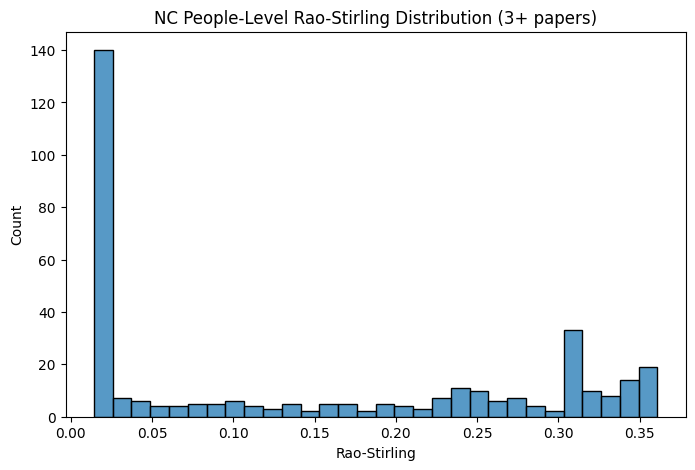

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(nc_people_3plus_df["rao_stirling"], bins=30)
plt.title("NC People-Level Rao-Stirling Distribution (3+ papers)")
plt.xlabel("Rao-Stirling")
plt.ylabel("Count")
plt.show()


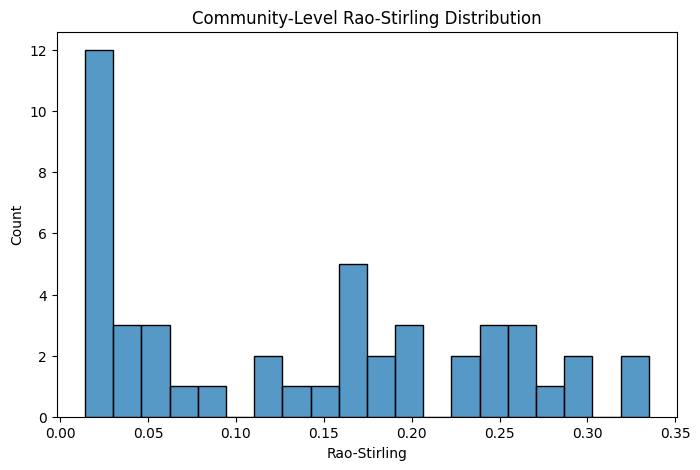

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(community_idr_df["rao_stirling"], bins=20)
plt.title("Community-Level Rao-Stirling Distribution")
plt.xlabel("Rao-Stirling")
plt.ylabel("Count")
plt.show()


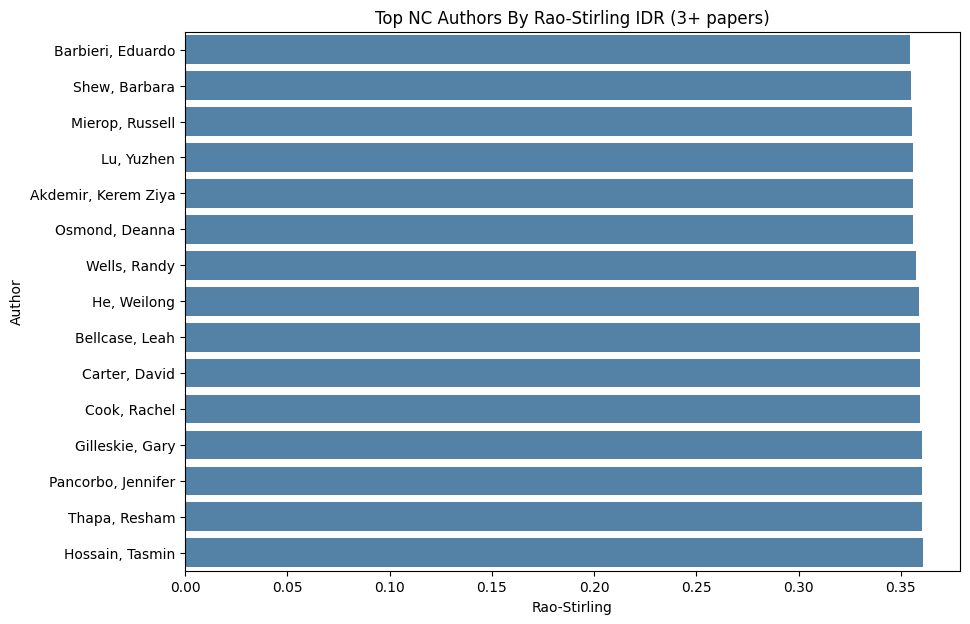

In [25]:
plot_df = nc_people_3plus_df.nlargest(15, "rao_stirling").sort_values("rao_stirling", ascending=True)
plt.figure(figsize=(10, 7))
sns.barplot(data=plot_df, x="rao_stirling", y="author", color="steelblue")
plt.title("Top NC Authors By Rao-Stirling IDR (3+ papers)")
plt.xlabel("Rao-Stirling")
plt.ylabel("Author")
plt.show()
